# 05 — Melnikov Function and Chaos Threshold

Plot $M(t_0)$ analytically and numerically; compute $F_{\mathrm{crit}}$ vs $\omega$ and vs $\delta$; validate by direct simulation. Note the spec's $F_{\mathrm{crit}}$ formula is corrected here — the leading factor is $c_1^{3/2}$ (not $c_1$).

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt

from steering.params import ModelParams, ForcingParams
from steering.models import (
    DuffingModel,
    BesselSteeringModel,
    ContinuousPFLModel,
    DiscretePFLModel,
    FullCircuitModel,
)
from steering.dynamics import VelocityDynamics, AccelerationDynamics
from steering.integrator import Simulation
from steering.visualization.style import use_paper_style

from steering.analysis.melnikov import (
    melnikov_analytical,
    melnikov_critical_forcing,
    melnikov_critical_forcing_numerical,
    melnikov_numerical,
)
from steering.analysis.homoclinic import numerical_homoclinic

use_paper_style()


In [2]:
neural = DiscretePFLModel(N_default = 12)

In [18]:

bessel = BesselSteeringModel()
p = ModelParams(kappa_h=1.0, kappa_g=1.0, delta=1.49)
c1, c3 = bessel.taylor_coefficients(p)
print(f'c1={c1:.3f}, c3={c3:.3f}')


c1=0.181, c3=-1.312


In [19]:
duffing = DuffingModel(c1, c3)

## Analytical $M(t_0)$ for several $(F, \omega)$

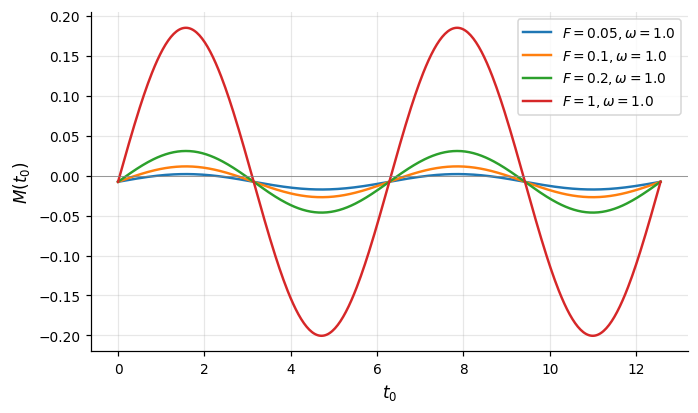

In [20]:
gamma = 0.1
t0 = np.linspace(0, 4*np.pi, 401)
fig, ax = plt.subplots(figsize=(7, 4))
for F in [0.05, 0.10, 0.20, 1]:
    for omega in [1.0]:
        M = melnikov_analytical(c1, c3, gamma, omega, F, t0)
        ax.plot(t0, M, label=fr'$F={F}, \omega={omega}$')
ax.axhline(0, color='0.5', lw=0.5)
ax.set_xlabel(r'$t_0$'); ax.set_ylabel(r'$M(t_0)$')
ax.legend(); plt.show()


## $F_{\mathrm{crit}}(\omega)$ — Duffing vs Bessel

Damping integral: 0.0780643849648609, cos_term: 0.0, sin_term: -0.6033542740059703
Damping integral: 0.0780643849648609, cos_term: -2.7755575615628914e-17, sin_term: -0.6954841604054429
Damping integral: 0.0780643849648609, cos_term: -6.938893903907228e-18, sin_term: -0.6292964382670405
Damping integral: 0.0780643849648609, cos_term: 1.3877787807814457e-17, sin_term: -0.5077573785872271
Damping integral: 0.0780643849648609, cos_term: 1.3877787807814457e-17, sin_term: -0.38494371264126104
Damping integral: 0.0780643849648609, cos_term: 2.7755575615628914e-17, sin_term: -0.2809428771158276
Damping integral: 0.0780643849648609, cos_term: 0.0, sin_term: -0.19986291390775912
Damping integral: 0.0780643849648609, cos_term: 1.3877787807814457e-17, sin_term: -0.1395760136334804
Damping integral: 0.0780643849648609, cos_term: 0.0, sin_term: -0.09610806869597135
Damping integral: 0.0780643849648609, cos_term: 0.0, sin_term: -0.06544153202357715
Damping integral: 0.0780643849648609, cos_term: 0.0

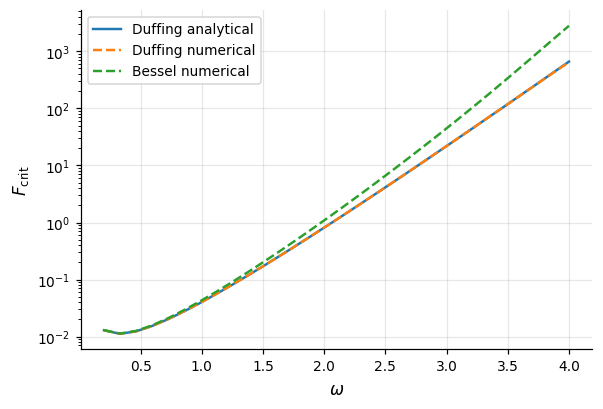

In [21]:
eps = 0.001
gamma = 0.1
omegas = np.linspace(0.2, 4.0, 30)
F_duff_a = np.array([melnikov_critical_forcing(c1, c3, gamma, om) for om in omegas])
homo = numerical_homoclinic(duffing, p)
t, th, v = homo
# homoclinic = () 
F_duff = np.array([melnikov_critical_forcing_numerical(duffing, p, gamma * eps, om, homoclinic=(t, *duffing.homoclinic_orbit(t))) for om in omegas]) / eps
# F_duff = np.array([melnikov_critical_forcing_numerical(duffing, p, gamma * eps, om, homoclinic=homo) for om in omegas]) / eps
homo = numerical_homoclinic(bessel, p)
F_bess = np.array([melnikov_critical_forcing_numerical(bessel, p, gamma * eps, om, homoclinic=homo) for om in omegas]) / eps
fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(omegas, F_duff_a, label='Duffing analytical')
ax.semilogy(omegas, F_duff, '--', label='Duffing numerical')
ax.semilogy(omegas, F_bess, '--', label='Bessel numerical')
ax.set_xlabel(r'$\omega$'); ax.set_ylabel(r'$F_{\mathrm{crit}}$')
ax.legend(); plt.show()


Damping integral: 0.07806438496479971, cos_term: 5.551115123125783e-17, sin_term: -0.603354274005832
Damping integral: 0.07806438496479971, cos_term: 2.7755575615628914e-17, sin_term: -0.6954841604054294
Damping integral: 0.07806438496479971, cos_term: 6.938893903907228e-18, sin_term: -0.6292964382670263
Damping integral: 0.07806438496479971, cos_term: 0.0, sin_term: -0.5077573785870823
Damping integral: 0.07806438496479971, cos_term: 0.0, sin_term: -0.3849437126409526
Damping integral: 0.07806438496479971, cos_term: 1.3877787807814457e-17, sin_term: -0.2809428771153898
Damping integral: 0.07806438496479971, cos_term: 0.0, sin_term: -0.19986291390725025
Damping integral: 0.07806438496479971, cos_term: -2.7755575615628914e-17, sin_term: -0.13957601363295663
Damping integral: 0.07806438496479971, cos_term: 0.0, sin_term: -0.09610806869547539
Damping integral: 0.07806438496479971, cos_term: -1.3877787807814457e-17, sin_term: -0.06544153202313605
Damping integral: 0.07806438496479971, cos_

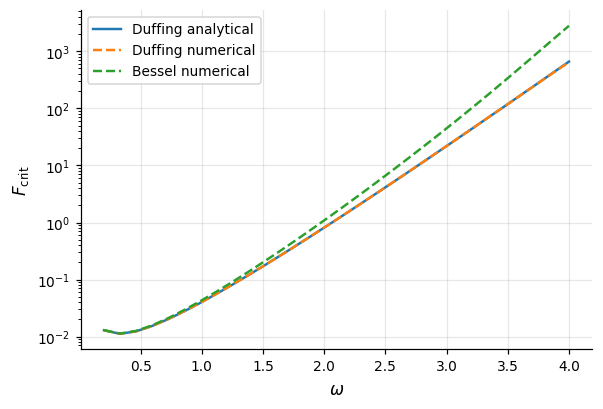

In [22]:
eps = 0.001
gamma = 0.1
omegas = np.linspace(0.2, 4.0, 30)
F_duff_a = np.array([melnikov_critical_forcing(c1, c3, gamma, om) for om in omegas])
homo = numerical_homoclinic(duffing, p)
t, th, v = homo
# homoclinic = () 
# F_duff = np.array([melnikov_critical_forcing_numerical(duffing, p, gamma * eps, om, homoclinic=(t, *duffing.homoclinic_orbit(t))) for om in omegas]) / eps
F_duff = np.array([melnikov_critical_forcing_numerical(duffing, p, gamma * eps, om, homoclinic=homo) for om in omegas]) / eps
homo = numerical_homoclinic(bessel, p)
F_bess = np.array([melnikov_critical_forcing_numerical(bessel, p, gamma * eps, om, homoclinic=homo) for om in omegas]) / eps
fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(omegas, F_duff_a, label='Duffing analytical')
ax.semilogy(omegas, F_duff, '--', label='Duffing numerical')
ax.semilogy(omegas, F_bess, '--', label='Bessel numerical')
ax.set_xlabel(r'$\omega$'); ax.set_ylabel(r'$F_{\mathrm{crit}}$')
ax.legend(); plt.show()


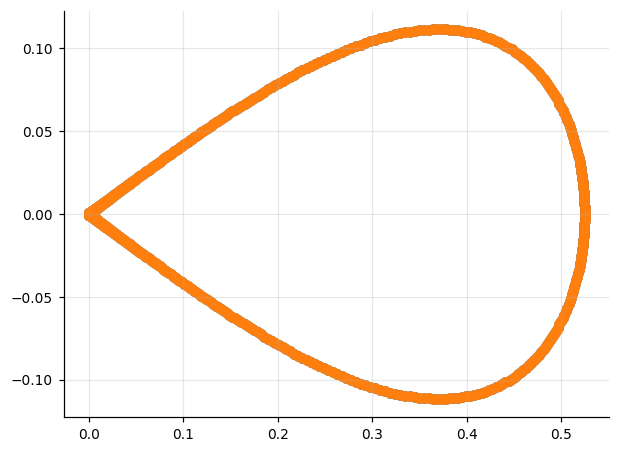

In [23]:
plt.scatter(duffing.homoclinic_orbit(t)[0], duffing.homoclinic_orbit(t)[1])
plt.scatter(th, v)

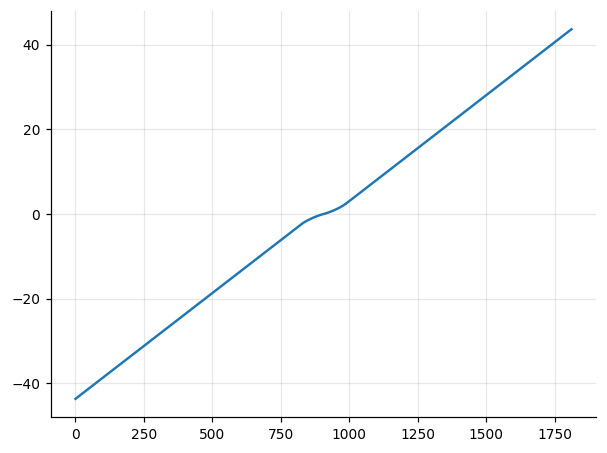

In [24]:
plt.plot(t)

## $F_{\mathrm{crit}}(\delta)$ at fixed $\omega$

Across $\delta$ values where the system is bistable. The minimum is the most chaos-susceptible separation.

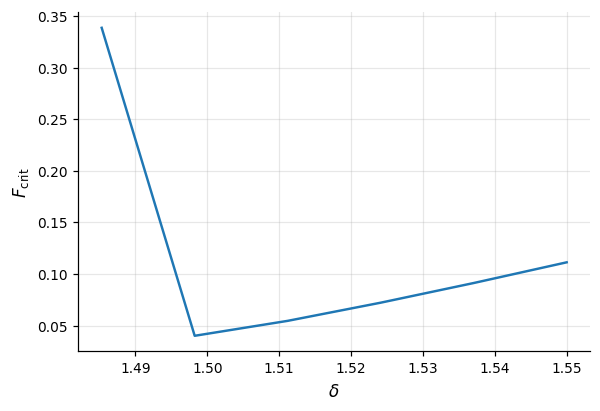

In [25]:
deltas = np.linspace(1.33, 1.55, 18)
F_duff = []
for d in deltas:
    pp = p.replace(delta=d)
    c1d, c3d = bessel.taylor_coefficients(pp)
    if c1d > 0 and c3d < 0:
        F_duff.append(melnikov_critical_forcing(c1d, c3d, gamma, 1.0))
    else:
        F_duff.append(np.nan)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(deltas, F_duff)
ax.set_xlabel(r'$\delta$'); ax.set_ylabel(r'$F_{\mathrm{crit}}$')
plt.show()


## Direct simulation validation

Pick $\omega=1$, $\gamma=0.05$, and three $F$ levels: below, near, and above $F_{\mathrm{crit}}$. Run long sims and inspect the Poincaré section.

In [27]:
p

ModelParams(kappa_h=1.0, kappa_g=1.0, delta=1.49, Delta_pop=1.1780972450961724, S=1.0, A=1.0, W_D3=0.0, Delta_pop_pfl2=3.141592653589793, N_neurons=None, nonlinearity='quadratic', nonlinearity_params={}, nonlinearity_pfl2=None)

F_crit (Duffing) = 0.4874


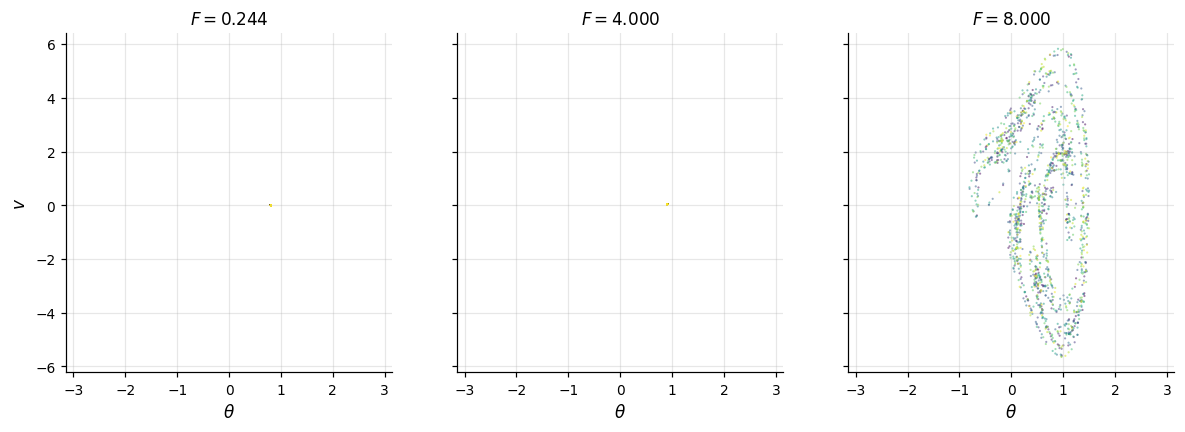

In [77]:
gamma = 0.15
from steering.analysis.poincare import stroboscopic_section
F_crit = melnikov_critical_forcing(c1, c3, gamma, 2.0)
print(f'F_crit (Duffing) = {F_crit:.4f}')
dyn = AccelerationDynamics(model=duffing, gamma=gamma)
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, F in zip(axes, [0.5*F_crit, 4, 8]):
    forc = ForcingParams(F=F, omega=2.0)
    sim = Simulation(dyn, p, forc, rtol=1e-9, atol=1e-11)
    T = 2*np.pi
    res = sim.run(np.array([0.5, 0.0]), (0.0, 800*T), dense_output=True)
    sec = stroboscopic_section(res, omega=2.0, transient_periods=50)
    ax.scatter(
        sec[:, 0],
        sec[:, 1],
        c=np.arange(len(sec)),
        cmap='viridis',
        s=2.0,
        alpha=0.5,
        linewidths=0,
    )
    ax.set_title(fr'$F={F:.3f}$')
    ax.set_xlabel(r'$\theta$')
    ax.set_xlim(-np.pi, np.pi)
axes[0].set_ylabel(r'$v$'); plt.show()



F_crit (Duffing) = 0.4874


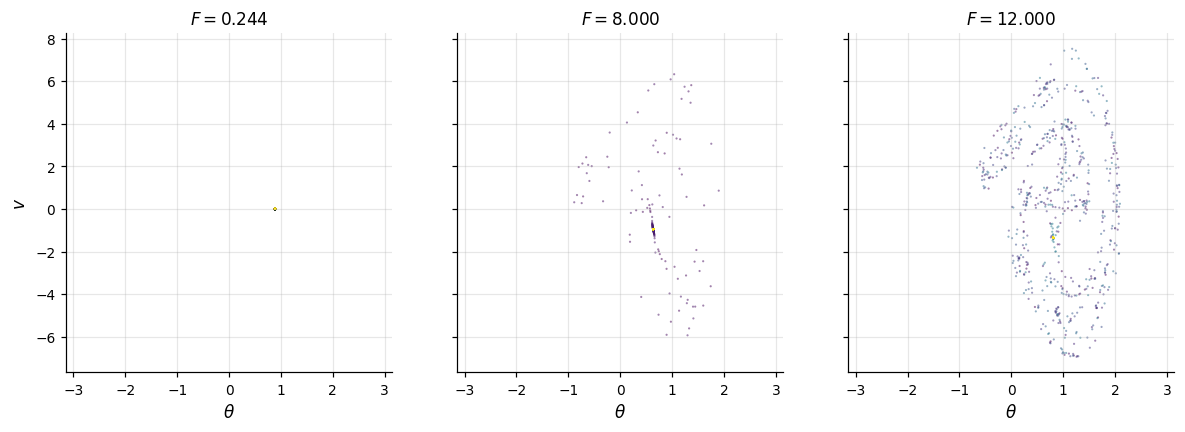

In [78]:
gamma = 0.15
from steering.analysis.poincare import stroboscopic_section
F_crit = melnikov_critical_forcing(c1, c3, gamma, 2.0)
print(f'F_crit (Duffing) = {F_crit:.4f}')
dyn = AccelerationDynamics(model=bessel, gamma=gamma)
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, F in zip(axes, [0.5*F_crit, 8, 12]):
    forc = ForcingParams(F=F, omega=2.0)
    sim = Simulation(dyn, p, forc, rtol=1e-9, atol=1e-11)
    T = 2*np.pi
    res = sim.run(np.array([0.5, 0.0]), (0.0, 800*T), dense_output=True)
    sec = stroboscopic_section(res, omega=2.0, transient_periods=50)
    ax.scatter(
        sec[:, 0],
        sec[:, 1],
        c=np.arange(len(sec)),
        cmap='viridis',
        s=2.0,
        alpha=0.5,
        linewidths=0,
    )
    ax.set_title(fr'$F={F:.3f}$')
    ax.set_xlim(-np.pi, np.pi)
    ax.set_xlabel(r'$\theta$')
axes[0].set_ylabel(r'$v$'); plt.show()



In [16]:
gamma = 0.15
from steering.analysis.poincare import stroboscopic_section
F_crit = melnikov_critical_forcing(c1, c3, gamma, 2.0)
F_crit

0.29520461239611295

In [51]:
c1, c3, F, gamma

(0.1807029593386969, -1.311999570271556, 0.16212695398188717, 0.1)

F_crit (Duffing) = 0.0119


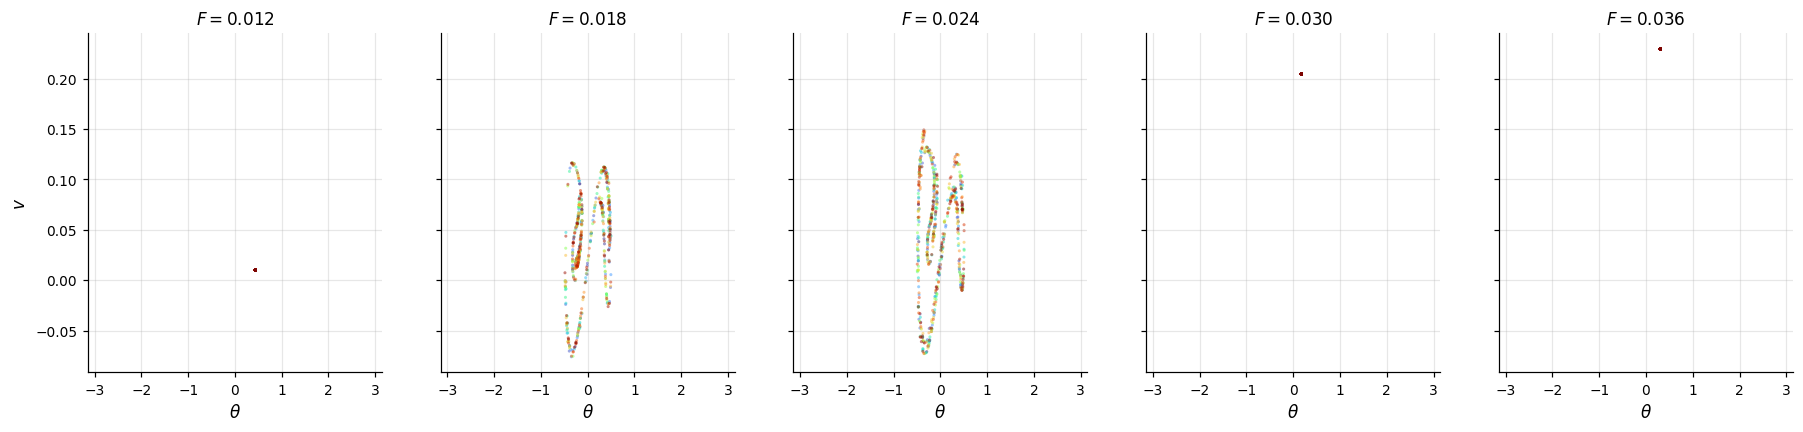

In [66]:
# eps = 0.001
eps = 1
gamma = 0.1
from steering.analysis.poincare import stroboscopic_section
omega = np.sqrt(c1) 
F_crit = melnikov_critical_forcing(c1, c3, gamma, omega)
print(f'F_crit (Duffing) = {F_crit:.4f}')
dyn = AccelerationDynamics(model=duffing, gamma=gamma * eps)
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
ax = axes[0]
secs = []
for ax, F in zip(axes, [F_crit * 1 * eps, F_crit * 1.5 * eps,  F_crit * 2 * eps, F_crit * 2.5 * eps, F_crit * 3 * eps]):
    forc = ForcingParams(F=F, omega=omega)
    sim = Simulation(dyn, p, forc, rtol=1e-9, atol=1e-11)
    T = 2*np.pi
    res = sim.run(np.array([0.01, 0.0]), (0.0, 1600*T), dense_output=True)
    sec = stroboscopic_section(res, omega=omega, transient_periods=50)
    secs.append(sec)
    ax.scatter(
        sec[:, 0],
        sec[:, 1],
        c=np.arange(len(sec)),
        cmap='turbo',
        s=4.0,
        alpha=0.5,
        linewidths=0,
    )
    ax.set_title(fr'$F={F:.3f}$')
    ax.set_xlim(-np.pi, np.pi)
    ax.set_xlabel(r'$\theta$')
axes[0].set_ylabel(r'$v$'); plt.show()



In [77]:
neural_ress = ress
neural_secs = secs

In [80]:
bessel_ress = ress
bessel_secs = secs

F_crit (Duffing) = 0.0119


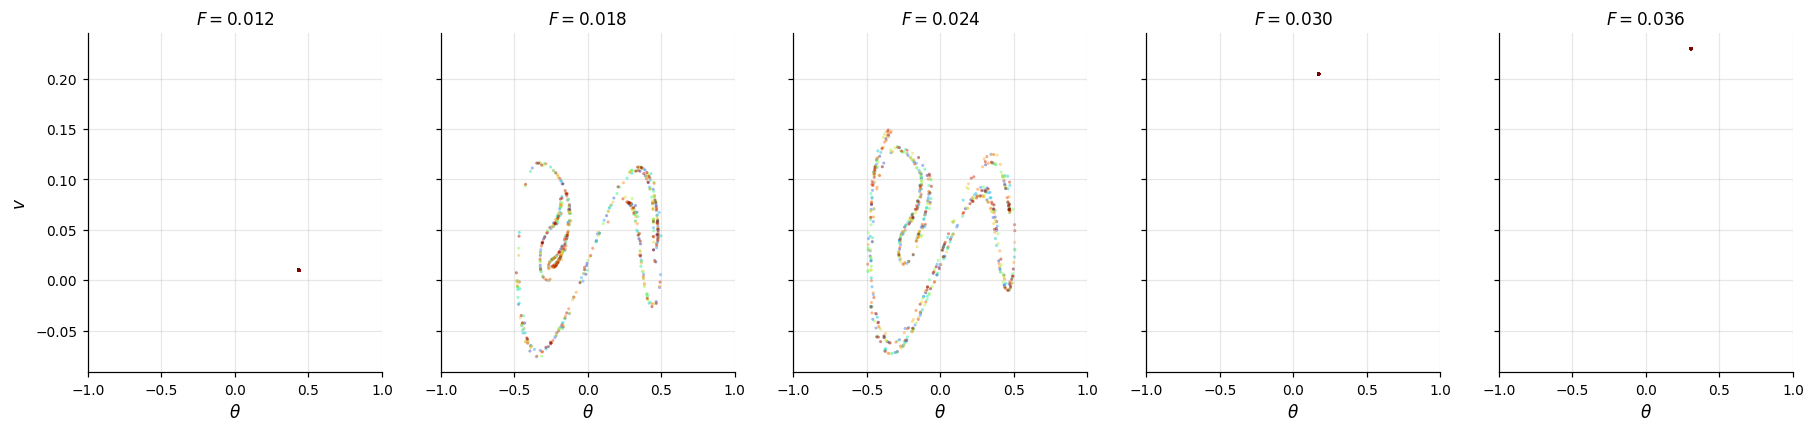

In [83]:
neural = DiscretePFLModel(N_default=6)
# eps = 0.001
eps = 1
gamma = 0.1
from steering.analysis.poincare import stroboscopic_section
omega = np.sqrt(c1) 
F_crit = melnikov_critical_forcing(c1, c3, gamma, omega)
print(f'F_crit (Duffing) = {F_crit:.4f}')
dyn = AccelerationDynamics(model=duffing, gamma=gamma * eps)
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
ax = axes[0]
ress = []
secs = []
for ax, F in zip(axes, [F_crit * 1 * eps, F_crit * 1.5 * eps,  F_crit * 2 * eps, F_crit * 2.5 * eps, F_crit * 3 * eps]):
    forc = ForcingParams(F=F, omega=omega)
    sim = Simulation(dyn, p, forc, rtol=1e-9, atol=1e-11)
    T = 2*np.pi
    res = sim.run(np.array([0.01, 0.0]), (0.0, 1600*T), dense_output=True)
    sec = stroboscopic_section(res, omega=omega, transient_periods=50)
    ress.append(res)
    secs.append(sec)
    ax.scatter(
        sec[:, 0],
        sec[:, 1],
        c=np.arange(len(sec)),
        cmap='turbo',
        s=4.0,
        alpha=0.5,
        linewidths=0,
    )
    ax.set_title(fr'$F={F:.3f}$')
    ax.set_xlim(-1, 1)
    ax.set_xlabel(r'$\theta$')
axes[0].set_ylabel(r'$v$'); plt.show()



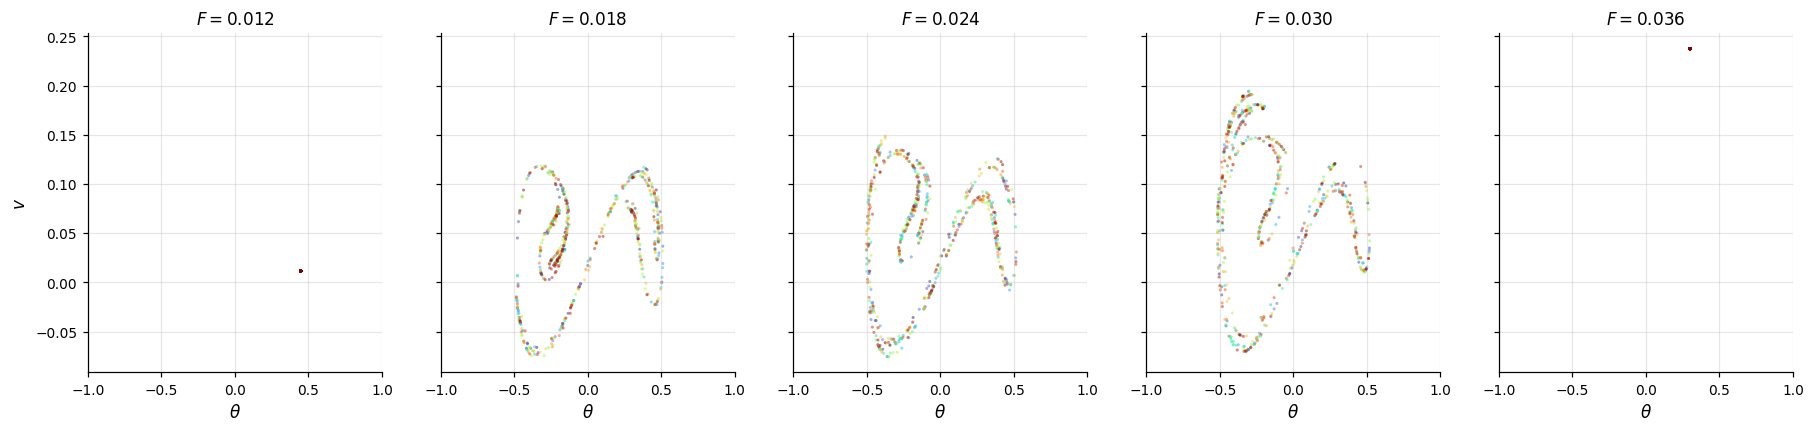

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
ax = axes[0]
for ax, F, sec in zip(axes, [F_crit * 1 * eps, F_crit * 1.5 * eps,  F_crit * 2 * eps, F_crit * 2.5 * eps, F_crit * 3 * eps], secs):
    ax.scatter(
        sec[:, 0],
        sec[:, 1],
        c=np.arange(len(sec)),
        cmap='turbo',
        s=4.0,
        alpha=0.5,
        linewidths=0,
    )
    ax.set_title(fr'$F={F:.3f}$')
    # ax.set_xlim(-np.pi, np.pi)
    ax.set_xlim(-1, 1)
    ax.set_xlabel(r'$\theta$')
axes[0].set_ylabel(r'$v$'); plt.show()

F_crit (Duffing) = 0.0119


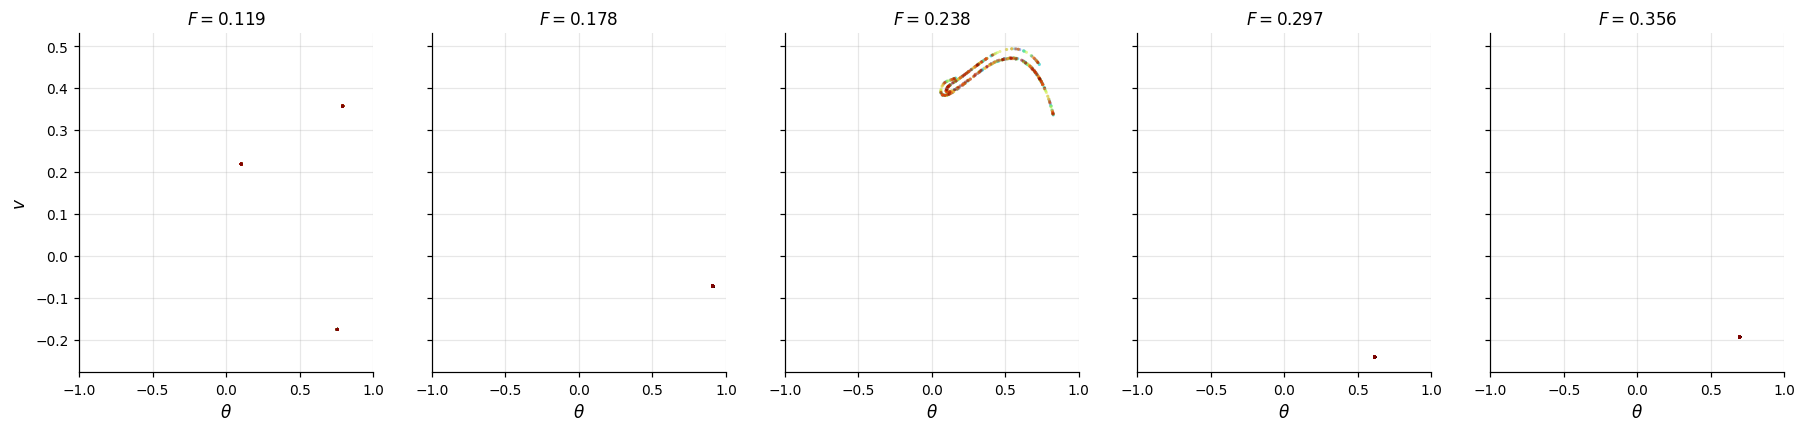

In [87]:
# eps = 0.001
eps = 1
gamma = 0.1
from steering.analysis.poincare import stroboscopic_section
omega = np.sqrt(c1) 
F_crit = melnikov_critical_forcing(c1, c3, gamma, omega)
print(f'F_crit (Duffing) = {F_crit:.4f}')
dyn = AccelerationDynamics(model=bessel, gamma=gamma * eps)
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
ax = axes[0]
secs = []
ress = []
for ax, F in zip(axes, [F_crit * 1 * eps, F_crit * 1.5 * eps,  F_crit * 2 * eps, F_crit * 2.5 * eps, F_crit * 3 * eps]):
    F =  10* F
    forc = ForcingParams(F=F, omega=omega)
    sim = Simulation(dyn, p, forc, rtol=1e-9, atol=1e-11)
    T = 2*np.pi
    res = sim.run(np.array([0.01, 0.0]), (0.0, 1600*T), dense_output=True)
    sec = stroboscopic_section(res, omega=omega, transient_periods=50)
    ress.append(res)
    secs.append(sec)
    ax.scatter(
        sec[:, 0],
        sec[:, 1],
        c=np.arange(len(sec)),
        cmap='turbo',
        s=4.0,
        alpha=0.5,
        linewidths=0,
    )
    ax.set_title(fr'$F={F:.3f}$')
    ax.set_xlim(-1, 1)
    ax.set_xlabel(r'$\theta$')
axes[0].set_ylabel(r'$v$'); plt.show()



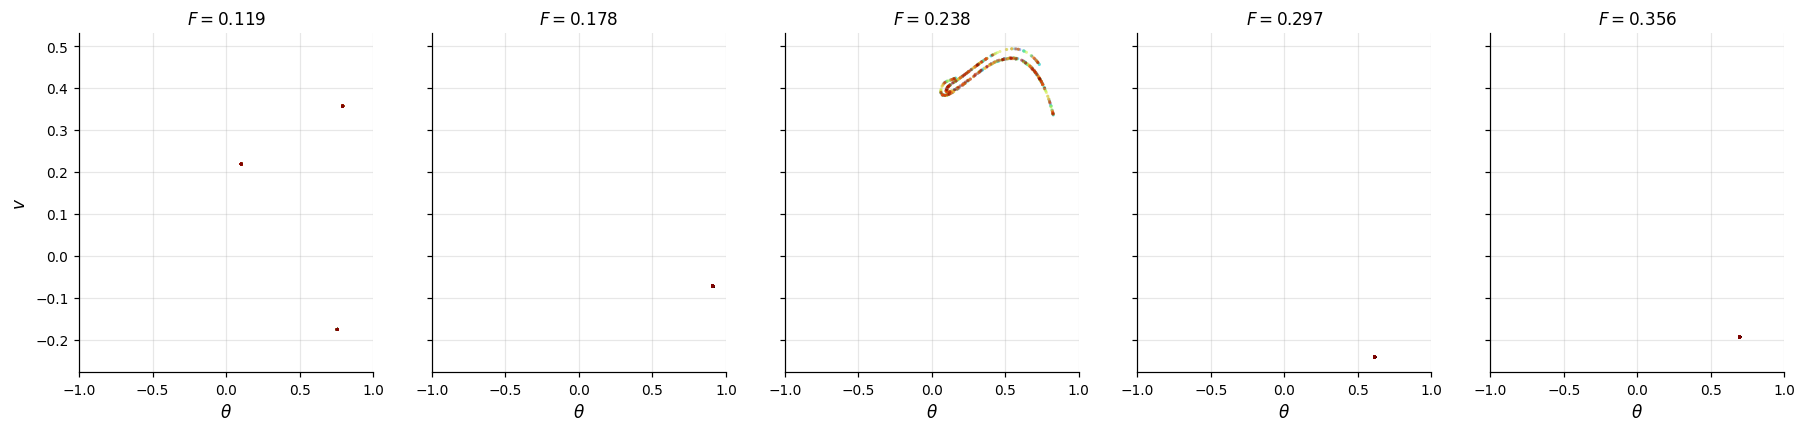

In [93]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
for i, (ax, F) in enumerate(zip(axes, [F_crit * 1 * eps, F_crit * 1.5 * eps,  F_crit * 2 * eps, F_crit * 2.5 * eps, F_crit * 3 * eps])):
    F =  10* F
    sec = secs[i]
    ax.scatter(
        sec[:, 0],
        sec[:, 1],
        c=np.arange(len(sec)),
        cmap='turbo',
        s=4.0,
        alpha=0.5,
        linewidths=0,
    )
    ax.set_title(fr'$F={F:.3f}$')
    ax.set_xlim(-1, 1)
    ax.set_xlabel(r'$\theta$')
axes[0].set_ylabel(r'$v$'); plt.show()




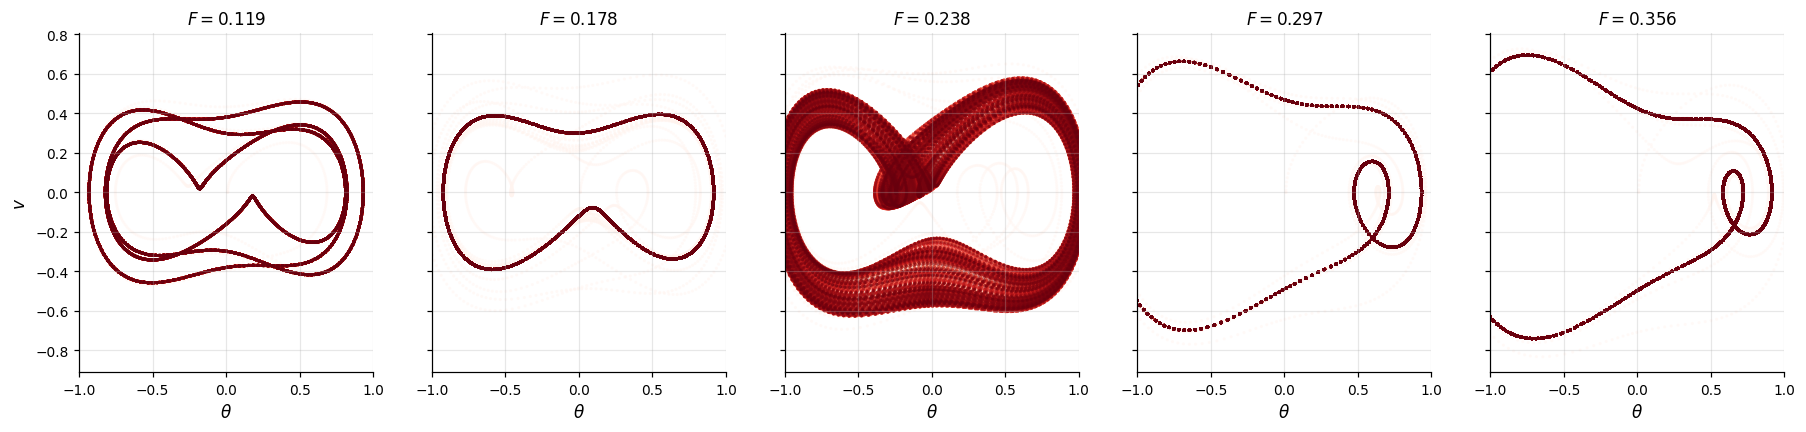

In [95]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
ax = axes[0]
for i, (ax, F)  in enumerate(zip(axes, [F_crit * 1 * eps, F_crit * 1.5 * eps,  F_crit * 2 * eps, F_crit * 2.5 * eps, F_crit * 3 * eps])):
    ax.scatter(
        ress[i].states[:, 0],
        ress[i].states[:, 1],
        c=np.arange(len(ress[i].states)),
        cmap='Reds',
        s=4.0,
        alpha=0.5,
        linewidths=0,
    )
    ax.set_title(fr'$F={F*10:.3f}$')
    ax.set_xlim(-1, 1)
    ax.set_xlabel(r'$\theta$')
axes[0].set_ylabel(r'$v$'); plt.show()


# plt.scatter(
#     ress[-1].states[:, 0],
#     ress[-1].states[:, 1],
#     c=np.arange(len(ress[-1].states)),
#     cmap='turbo',
#     s=2.0,
#     alpha=0.5,
#     linewidths=0,
# )

In [96]:
omega

0.42509170697473847

In [41]:
res.__dict__.keys()

dict_keys(['t', 'states', 'dynamics', 'params', 'forcing', 'sol', 'success', 'message'])

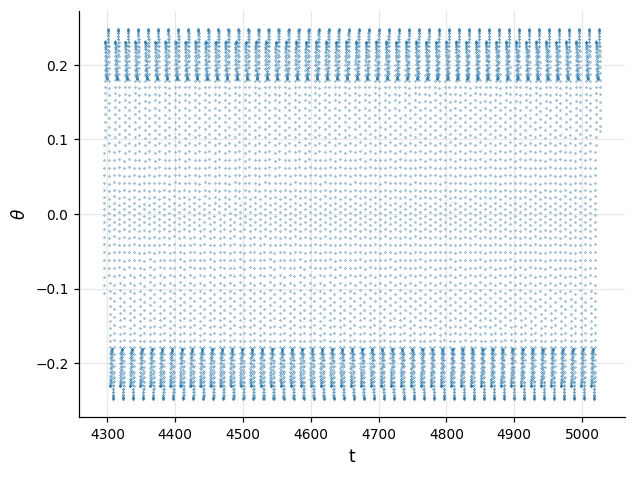

In [59]:
plt.scatter(res.t[-10000:], res.states[-10000:, 1], s=0.1); plt.xlabel('t'); plt.ylabel(r'$\theta$'); plt.show()

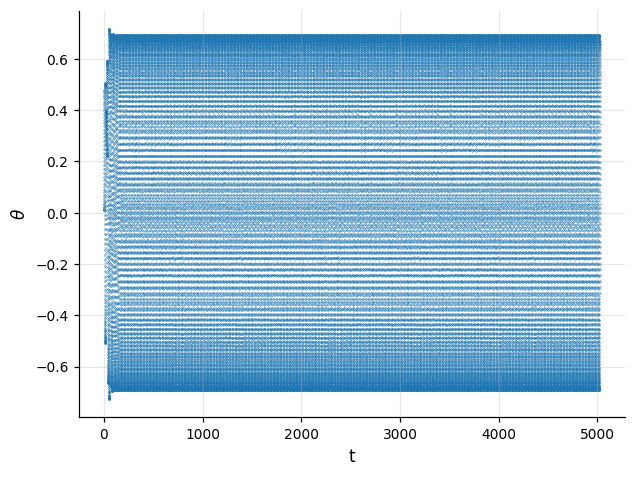

In [60]:
plt.scatter(res.t, res.states[:, 0], s=0.1); plt.xlabel('t'); plt.ylabel(r'$\theta$'); plt.show()

In [ ]:
plt.scatter(res.t, res.states[:, 0], s=0.1); plt.xlabel('t'); plt.ylabel(r'$\theta$'); plt.show()

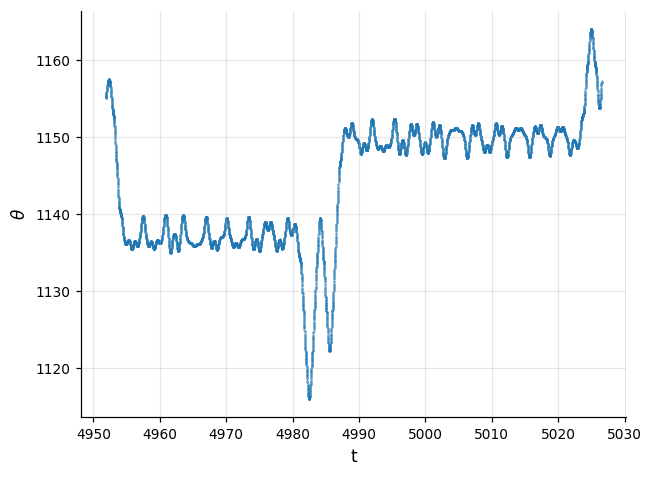

In [142]:
plt.scatter(res.t[-8000:], res.states[-8000:, 0], s=0.1); plt.xlabel('t'); plt.ylabel(r'$\theta$'); plt.show()